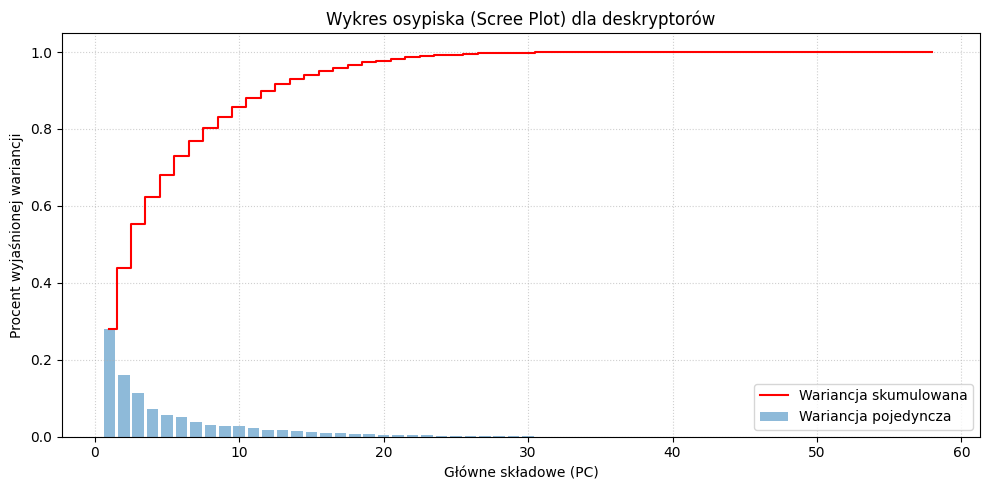

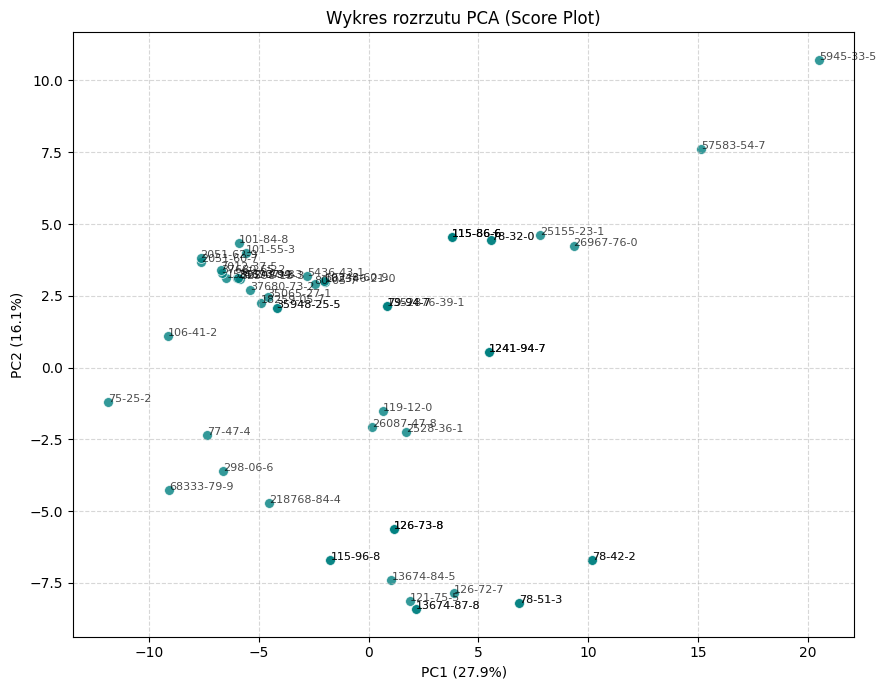

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sciezka_pliku = './deskryptory_z_cas.xlsx'

df = pd.read_excel(sciezka_pliku)

df.set_index(df.columns[0], inplace=True)

X = df.select_dtypes(include=[np.number]).dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Wariancja pojedyncza')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Wariancja skumulowana', color='red')
plt.ylabel('Procent wyjaśnionej wariancji')
plt.xlabel('Główne składowe (PC)')
plt.title('Wykres osypiska (Scree Plot) dla deskryptorów')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'], index=X.index)

plt.figure(figsize=(9, 7))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', alpha=0.8, color='teal', edgecolor='w', s=50)

plt.title('Wykres rozrzutu PCA (Score Plot)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)

for i, txt in enumerate(pca_df.index):
     plt.annotate(txt, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()
